# 02 — What are we predicting?

A model is only as sensible as the question you point it at. This notebook
defines that question precisely.

Three things get settled here: what the outcome column actually contains, how we
turn it into something a model can predict, and **how common the thing we're
predicting is** — which turns out to be the number that governs how every later
result should be read.


In [1]:
import sys
from pathlib import Path

REPO = Path.cwd()
while not (REPO / "src" / "oulad").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from oulad import load, viz
from oulad import labels as lab

viz.use_project_style()
pd.set_option("display.width", 100)
pd.set_option("display.max_columns", 30)

tables = load.load_all(verbose=False)
student_info = tables["studentInfo"]
print("loaded")

loaded


## The outcome column

`final_result` is what the university recorded at the end of each enrolment. It
takes four values.

In [2]:
counts = student_info["final_result"].value_counts()
pct = student_info["final_result"].value_counts(normalize=True) * 100

pd.DataFrame({"count": counts, "percent": pct.round(1)})

,count,percent
final_result,,
Pass,12361,37.9
Withdrawn,10156,31.2
Fail,7052,21.6
Distinction,3024,9.3


- **Pass** — completed and passed.
- **Distinction** — passed well.
- **Fail** — stayed enrolled to the end but didn't pass.
- **Withdrawn** — left before the end.

The difference between Fail and Withdrawn matters and is easy to skate over.
`Fail` is a *state* discovered at the end of the course. `Withdrawn` is an
**event with a date attached**, and that date is recorded. Notebook 03 is
entirely about the consequences of that.

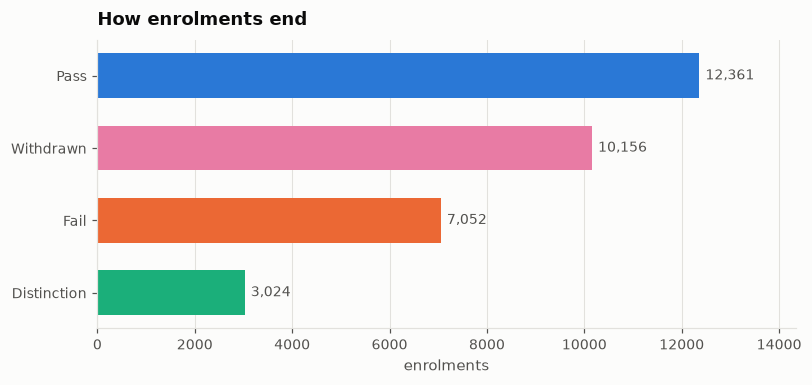

In [3]:
order = ["Pass", "Withdrawn", "Fail", "Distinction"]
vals = [counts[o] for o in order]
colors = [viz.OUTCOME_COLORS[o] for o in order]

fig, ax = plt.subplots(figsize=(7.5, 3.6))
bars = ax.barh(order[::-1], vals[::-1], color=colors[::-1], height=0.62)
ax.bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=9, color=viz.INK_SOFT)
ax.set_xlim(0, max(vals) * 1.16)
ax.set_xlabel("enrolments")
ax.set_title("How enrolments end")
ax.grid(axis="y", visible=False)
viz.show(fig)

## Collapsing four outcomes into two

We want a model that answers a yes/no question, because the action it feeds is
yes/no: a tutor either reaches out to a student or doesn't.

So:

| Original | Becomes |
|---|---|
| `Fail`, `Withdrawn` | **1** — "at risk" |
| `Pass`, `Distinction` | **0** — "not at risk" |

**Why group Fail and Withdrawn?** Both describe someone who didn't get the
qualification they enrolled for, and both warrant the same first response —
a conversation. They aren't the same phenomenon, and separating them is a
worthwhile extension later, but for a first model they share an intervention.

**Why not keep four classes?** The decision is binary anyway, so a four-way
model would have to be collapsed to act on. And splitting the training signal
across four categories makes each one harder to learn.

The word for the value we're predicting is the **target** or **label** — you'll
see both, they mean the same thing. The 1 category is called the **positive
class**, which does not mean "good"; it means "the thing we're trying to
detect".

In [4]:
labels = lab.build_labels(student_info, tables["studentRegistration"])
labels[["id_student", "code_module", "final_result", "at_risk", "withdrew"]].head()

  note: 9 enrolments have an unregistration date but a non-Withdrawn outcome.


,id_student,code_module,final_result,at_risk,withdrew
0,11391,AAA,Pass,0,0
1,28400,AAA,Pass,0,0
2,30268,AAA,Withdrawn,1,1
3,31604,AAA,Pass,0,0
4,32885,AAA,Pass,0,0


In [5]:
base_rate = labels["at_risk"].mean()

print(f"at risk (1)     : {labels['at_risk'].sum():>7,}")
print(f"not at risk (0) : {(1 - labels['at_risk']).sum():>7,}")
print(f"total           : {len(labels):>7,}")
print()
print(f"base rate       : {base_rate:.3f}   ({base_rate * 100:.1f}%)")

at risk (1)     :  17,208
not at risk (0) :  15,385
total           :  32,593

base rate       : 0.528   (52.8%)


## 52.8%. Sit with that number for a second.

The **base rate** (also called *prevalence*) is the share of cases that are
positive. Here it's 52.8% — **more than half of all enrolments end in Fail or
Withdrawn.**

That is higher than most people guess, and it changes how this problem should be
described. A lot of writing about early-warning systems assumes you're hunting
for a rare event — fraud, disease, equipment failure — where positives are maybe
1% of cases. Techniques and metrics built for that situation don't
straightforwardly apply here, because **our positive class is the majority
class.** Distance learning is genuinely hard.

The base rate is also the number every model result has to be compared against,
because you can achieve it without a model at all.

### Why accuracy is the wrong metric — demonstrated

**Accuracy** is the fraction of predictions you got right. Watch what a model
that does no work at all scores.

In [6]:
# The laziest possible "model": say everyone is at risk.
always_at_risk = np.ones(len(labels))
accuracy = (always_at_risk == labels["at_risk"]).mean()

print(f'"Everyone is at risk"  -> accuracy {accuracy:.3f}')

# And the opposite.
always_safe = np.zeros(len(labels))
print(f'"Nobody is at risk"    -> accuracy {(always_safe == labels["at_risk"]).mean():.3f}')

"Everyone is at risk"  -> accuracy 0.528
"Nobody is at risk"    -> accuracy 0.472


Both score near 50%, which is roughly a coin flip — so on *this* dataset
accuracy isn't wildly inflated the way it would be on a rare-event problem.

But it's still the wrong metric, for two reasons that have nothing to do with
the base rate:

1. **It forces a threshold.** A model outputs a score between 0 and 1, not a
   decision. Turning that into "flag / don't flag" requires picking a cut-off,
   and the right cut-off depends on how many students a tutor can actually
   contact this week. That's a deployment decision, not a property of the model.

2. **It treats both mistakes as equally bad.** Missing an at-risk student and
   wasting a tutor's hour on someone who was fine are both "one wrong answer" to
   accuracy. They are not remotely the same thing.

What we'll use instead is covered in notebook 03 and in `docs/01-glossary.md`.
The short version: measure the *ranking*, because the product is a ranked list.

### What "flag the at-risk students" can't mean

If 52.8% of enrolments are positive, a model that flags everyone it believes is
at risk would hand a tutor half the cohort. That isn't an intervention plan.

So the output has to be a **ranking** — students ordered by risk, worked down as
far as time allows. This is why we'll later care about a metric like
"of the top 10% we flagged, how many really were at risk" rather than any
overall correctness score.

## Students repeat, and it changes how we must test

Back to something notebook 01 turned up.

In [7]:
n_students = labels["id_student"].nunique()
n_rows = len(labels)

print(f"distinct students : {n_students:,}")
print(f"enrolments        : {n_rows:,}")
print(f"difference        : {n_rows - n_students:,} enrolments are repeat appearances")

distinct students : 28,785
enrolments        : 32,593
difference        : 3,808 enrolments are repeat appearances


To find out whether a model works, you hold back some data, build the model
on the rest, and check its predictions against the part you held back. The held
back part is the **test set**; the rest is the **training set**.

The point is to estimate performance on students the model has never seen —
because that's the only situation it will ever be used in.

Now: if you split the 32,593 rows at random, the same person can land in both
sets. The model can then recognise *that individual* rather than learn the
general pattern, and your test score is measuring something easier than reality.
That's a form of **leakage** — information reaching the model that wouldn't be
available when it's really used.

**The fix:** split by *student*, not by row, so all of a person's enrolments stay
on the same side. The tool for it is `GroupKFold`, grouping on `id_student`. We
use it from the first model onward.

## Does risk vary by course?

A quick look, mostly to establish that the outcome isn't uniform.

In [8]:
by_module = (
    labels.groupby("code_module")
    .agg(at_risk_rate=("at_risk", "mean"), enrolments=("at_risk", "size"))
    .sort_values("at_risk_rate", ascending=False)
)
by_module["at_risk_rate"] = by_module["at_risk_rate"].round(3)
by_module

,at_risk_rate,enrolments
code_module,,
CCC,0.622,4434
DDD,0.584,6272
FFF,0.530,7762
BBB,0.525,7909
EEE,0.438,2934
GGG,0.403,2534
AAA,0.290,748


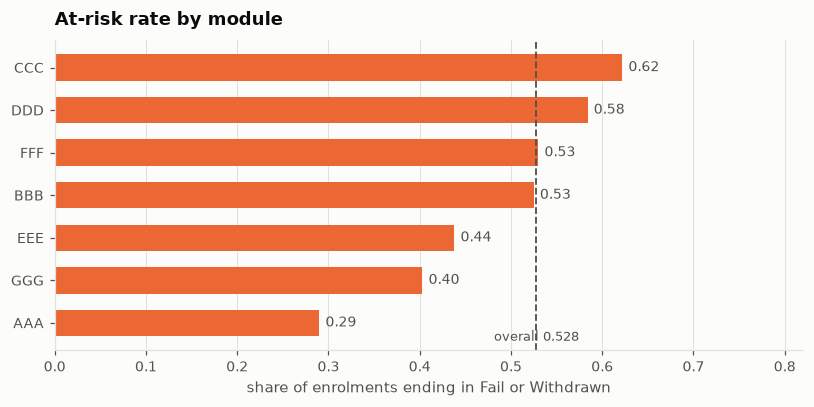

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
b = ax.barh(by_module.index[::-1], by_module["at_risk_rate"][::-1],
            color=viz.AT_RISK, height=0.62)
ax.bar_label(b, fmt="{:.2f}", padding=4, fontsize=9, color=viz.INK_SOFT)
ax.axvline(base_rate, color=viz.INK_SOFT, linestyle="--", linewidth=1.2)
ax.annotate(f"overall {base_rate:.3f}", xy=(base_rate, -0.42),
            fontsize=8.5, color=viz.INK_SOFT, ha="center")
ax.set_xlim(0, 0.82)
ax.set_xlabel("share of enrolments ending in Fail or Withdrawn")
ax.set_title("At-risk rate by module")
ax.grid(axis="y", visible=False)
viz.show(fig)

Real spread — the hardest module runs well above the easiest.

Note the colour choice: every bar is the same colour. It's tempting to shade
them darker-where-bigger, but the bar length already encodes size, and using
colour to repeat it wastes the one channel you have left for showing something
new. Colour should carry *identity*, not magnitude.

Two readings, and we can't yet tell them apart:

- Some modules are genuinely harder.
- Some modules attract students who were more likely to struggle anyway.

Untangling those needs more than a bar chart, and honestly may not be possible
with this data. Worth flagging now so we don't quietly assume the first one.

## What to take away

1. **The target** is binary: 1 for Fail or Withdrawn, 0 for Pass or Distinction.
2. **The base rate is 52.8%** — the positive class is the majority. This is not a
   rare-event problem, and advice written for rare events doesn't transfer.
3. **Accuracy is out** — it forces an arbitrary threshold and treats both error
   types as equal.
4. **The output must be a ranking**, because flagging half a cohort isn't an
   intervention.
5. **Splits must group on `id_student`**, because 3,808 enrolments are repeat
   appearances.

Next: [`03-the-population-question.ipynb`](03-the-population-question.ipynb) —
which turns out to matter more than everything above.